<a href="https://colab.research.google.com/github/SauravSG/Deep-Learning/blob/main/CH_02_Neural_Network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CH 02 - Neural Network Classification with PyTorch**

Classification is a problem of predicting the labels / class (there could be multiple things options)

### 1. Make classification data and get it ready

In [ ]:
import sklearn

**Note:** The dataset we are going to use in here refers to *toy datasets*, a dataset that is small but enough to do experiments in order to learn the fundamentals.

### **make_circles:**
is a synthetic data generator, not a real dataset.

That means:

It does NOT store fixed data

It does NOT load data from disk

It CREATES data mathematically every time you call it.

Hence we are giving it number of samples, noise (to make the datapoints less crowdy which we will see in visualization) and random_state to keep the consistency of the data generated.

This make_circles now has 1000 datapoints, with 2 features (X1, X2) and 2 labels (0, 1)

In [ ]:
from sklearn.datasets import make_circles

# make 1000 samples
n_samples = 1000

# create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)

In [ ]:
print(len(X))

print(len(y))

1000
1000


In [ ]:
print(f'first 5 samples of X: \n{X[:5]} \n')
print( f'first 5 samples of y: \n {y[:5]}')
# the y will give 0s and 1s which tells that there are only 2 classes means it's a binary classification

first 5 samples of X: 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]] 

first 5 samples of y: 
 [1 1 1 1 0]


In [ ]:
# Make dataframe of the circle data - converting the raw generated data into a DataFrame
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                         "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


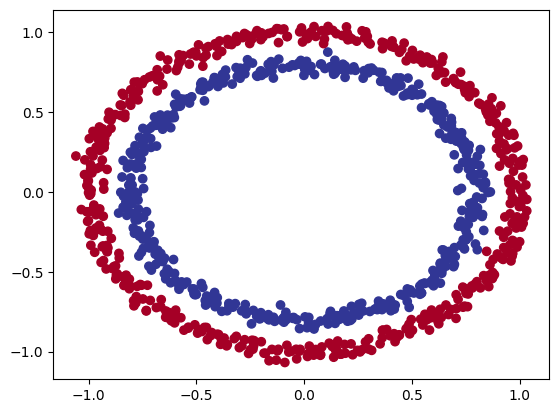

In [ ]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)  # using c=y means colors for 2 samples from y and cmap is colour map where it maps among the Red, yellow and Blue colors.

### 1.1 Check input and output shapes

In [ ]:
# View the first samples of features and labels
X_sample = X[0]
y_sample = y[0]

print(f'Values for one sample of X: {X_sample} and the same for y: {y_sample} \n')
print(f'Shapes of one sample of X: {X_sample.shape} and for y: {y_sample.shape}')
# for y_sample we will get "()" means its scaler

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1 

Shapes of one sample of X: (2,) and for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [ ]:
import torch

In [ ]:
X[:5] # This confirms that X is numpy array at the moment
# or we can do
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
# Turn data into tensor
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
print(type(X), X.dtype, y.dtype)

<class 'torch.Tensor'> torch.float32 torch.float32


In [ ]:
# split data into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)

In [ ]:
print(len(X_train),  len(X_test), len(y_train), len(y_test))

800 200 800 200


### 2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelarator (GPU) if there is one.
2. Construct a model (by subclassing `nn.module`)
3. Define a loss function and optimizer
4. Create a training and testing loop

In [ ]:
# import PyTorch and nn
import torch
from torch import nn

# Make device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [ ]:
print(X_train)

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])


Now we setup device agnostic code, let's create a model that:
1. subclasses `nn.module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` that outlines the forward pass of the model
4. Instantiate an instance of our model class and send it to the target `device`

In [ ]:
print(X_train.shape)

torch.Size([800, 2])


In [ ]:
print(y_train[:5])

tensor([1., 0., 0., 0., 1.])


In [ ]:
# 1. Construct a model that subclasses nn.Module

class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    # 2. create 2 nn.Linear() layers capable of handling shapes of our data

    self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and transform into 5 laters
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features from previous layer and output a single feature (same shape as y)

  # 3. define forward() method that outlines the forward pass
  def forward(self, x):
    return self.layer_2(self.layer_1(x)) # x goes into layer 1 and then layer 2 and then layer 2 goes to output

# 4. instantiate the model class and send it to target device

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

**What is nn.Linear?**

class `torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)`


A fully connected layer (also called dense layer)
Performs the operation: `output = input × weights + bias`
Every input connects to every output

Breaking down the parameters:
`in_features=2`

Number of input features
Your data X has shape `[1000, 2]` - each sample has 2 features (x1, x2)
The layer expects to receive 2 values per sample

`out_features=5`

Number of output features (neurons in this layer)
The layer will produce 5 values per sample
This is a hyperparameter you choose - could be 3, 10, 100, etc.

What nn.Linear creates internally:
python# Internally, nn.Linear creates:
`self.layer_1.weight = torch.randn(5, 2)`  # Shape: [out_features, in_features]
`self.layer_1.bias = torch.randn(5) `      # Shape: [out_features]


**The math this layer performs:**

For one sample with input `[x1, x2]`:

Input: [x1, x2]  (shape: [2])

Weights matrix (5×2):
[w11  w12]
[w21  w22]
[w31  w32]
[w41  w42]
[w51  w52]

Bias vector (5):
[b1, b2, b3, b4, b5]

Operation:
output[0] = w11*x1 + w12*x2 + b1
output[1] = w21*x1 + w22*x2 + b2
output[2] = w31*x1 + w32*x2 + b3
output[3] = w41*x1 + w42*x2 + b4
output[4] = w51*x1 + w52*x2 + b5

Output: [output[0], output[1], output[2], output[3], output[4]  (shape: [5])


**In matrix form:**

output = input @ weights.T + bias
[5] = [2] @ [5×2].T + [5]
[5] = [2] @ [2×5] + [5]
Example with actual numbers:
python# Input
x = [0.5, -0.3]

-> Assume random weights and biases
weights = [[0.2, 0.4],
           [0.1, -0.3],
           [0.5, 0.2],
           [-0.1, 0.6],
           [0.3, -0.2]]

bias = [0.1, 0.2, 0.3, 0.4, 0.5]

-> Calculate output
output[0] = 0.2*0.5 + 0.4*(-0.3) + 0.1 = 0.1 - 0.12 + 0.1 = 0.08

output[1] = 0.1*0.5 + (-0.3)*(-0.3) + 0.2 = 0.05 + 0.09 + 0.2 = 0.34

output[2] = 0.5*0.5 + 0.2*(-0.3) + 0.3 = 0.25 - 0.06 + 0.3 = 0.49

output[3] = (-0.1)*0.5 + 0.6*(-0.3) + 0.4 = -0.05 - 0.18 + 0.4 = 0.17

output[4] = 0.3*0.5 + (-0.2)*(-0.3) + 0.5 = 0.15 + 0.06 + 0.5 = 0.71

Output = [0.08, 0.34, 0.49, 0.17, 0.71]

Your comment:

"takes in 2 features and upscale to 5 features"

Correction: It's not "upscaling" - it's transforming. The layer takes 2 input values and produces 5 output values through learned linear combinations. Each of the 5 outputs is a weighted sum of the 2 inputs.

PART 4: Layer 2 - Second Linear Layer
pythonself.layer_2 = nn.Linear(in_features=5, out_features=1)
What it does:

Takes the 5 outputs from layer_1 as input
Produces 1 output value (the prediction)

Breaking down the parameters:
in_features=5

Matches the output of layer_1
The layer expects 5 values as input

out_features=1

Single output (binary classification prediction)
This matches your y labels which have shape [1000] (one value per sample)

What nn.Linear creates internally:
pythonself.layer_2.weight = torch.randn(1, 5)  # Shape: [1, 5]
self.layer_2.bias = torch.randn(1)       # Shape: [1]


**The math this layer performs:**

Input from layer_1: [v1, v2, v3, v4, v5]  (shape: [5])

Weights: [w1, w2, w3, w4, w5]  (shape: [5])
Bias: b

Operation:
output = w1*v1 + w2*v2 + w3*v3 + w4*v4 + w5*v5 + b

Output: single number (shape: [1])
Example:
python# Input from layer_1
layer_1_output = [0.08, 0.34, 0.49, 0.17, 0.71]

-> Assume weights and bias
weights = [0.5, -0.3, 0.2, 0.4, -0.1]
bias = 0.2

-> Calculate
output = 0.5*0.08 + (-0.3)*0.34 + 0.2*0.49 + 0.4*0.17 + (-0.1)*0.71 + 0.2
output = 0.04 - 0.102 + 0.098 + 0.068 - 0.071 + 0.2
output = 0.233

-> This single number is the model's prediction

In [ ]:
model_0.state_dict()
# this would give the random weights and bias for layer_1 and layer_2. In case of layer_2, the number of elements gotten less like we saw in the above math example.

OrderedDict([('layer_1.weight',
              tensor([[-0.6973,  0.1987],
                      [ 0.1761, -0.3313],
                      [ 0.2482, -0.4676],
                      [ 0.3297, -0.5090],
                      [ 0.5224, -0.4648]])),
             ('layer_1.bias',
              tensor([ 0.5377, -0.3368, -0.0879,  0.6787,  0.6163])),
             ('layer_2.weight',
              tensor([[-0.3438, -0.0473,  0.1094, -0.1576,  0.0659]])),
             ('layer_2.bias', tensor([-0.0666]))])

In [ ]:
# Make predictions
with torch.inference_mode(): # if we don't do this then the gradients will be tracked.
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions: \n{torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 samples: \n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]])

First 10 samples: 
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

-> This is problem specific.

For ex,

- For regression you might want MAE (Mean Absolute Error) or MSE (Mean Squared Error)

- For classification you might want binary cross entropy or categorical cross entropy (cross entropy).

As a reminder, the loss function measures how *wrong* your model's predictions are.

And for optimizers, two of the most common and useful are SGD and Adam, however, PyTorch has many built-in options.

* For the loss function, we're going to use `torch.nn.BCEWithLogitsLoss()`


In [ ]:
 # Setup loss function & optimizer
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss() is a sigmoid activation function

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1) # this will optimize the parameters or model)0.state_dict() if for more simple understanding

In [ ]:
# Evaluation metric:
# Calculate Accuracy - True positive / (True positive + True negative) * 100 i.e.

def accuracy(y_true, y_pred):

  correct = torch.eq(y_true, y_pred).sum().item() # -> Compares each element in y_true and y_pred.
  # Returns a tensor of booleans (True where predictions are correct).
  # .sum() - counts how many predictions are correct (True -> 1)
  # .item() - Converts the result from a PyTorch tensor to a Python number.
  accuracy = (correct/len(y_pred))*100 # Computes the fraction of correct predictions.
  return accuracy

### 3. Train Model

To train our model, we are going to build training loop:

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimzer step (gradient descent)


### 3.1 Let's go from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to raw **logits**.

**Logits:**
**Logits** are the raw, unnormalized output scores generated by the last layer og NN **before** they are passed through an activation function like sigmoid or softmax.

These are like the model's "unfiltered" opinion.

**Where do logits live?**

The final stages of classification model looks like:
1. **Linear layer:** The model does its final math `(y=m.T@x + b)`. The results are set of numbers and these numbers are the **Logits**.
2. **Sofmax layer:** The logits are squashed into a probability distribution (where all numbers are between 0 and 1 and sum to 100%).
3. **Output:** The predictitions.

When these are numbers are squashed between 0 to 1, it helps to predict the labels or the probability of a class (as in an image being of a cat or dog)

Directly using the raw logits or the predictions would cause system crash. FOr softmax , the calculation requires *e^x* and of *x*=100, this can crash the computer's memory.

Logit provides a "steeper" gradient. When a model is very confident and the probability is 0.999, the gradient (the slope) becomes almost flat, making it hard for the model to learn. Logits keep the "signal" alive for longer.

Logits are mainly required in classification as we are predictioon the class or the label. In case of regression, the final output is a number only, so we don't need to squash it and convert into some probability.

So in short,
We convert these logits into prediction probabilities by passing them to some activation function (e.g. sigmoid for binary classification and softmax for multiclass classification)

Then we convert our model's prediciton probabilities to **prediciton lables** by either rounding them or taking the `argmax()`.

In [ ]:
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# View the first five outputs of the forward pass on the test data

# We will do this with inference mode as we are currently predicting and not training so we don't need the gradient tracking
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
print(y_logits)

tensor([[-0.4389],
        [-0.3598],
        [-0.4638],
        [-0.4326],
        [-0.1741]])


In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use the sigmoid activation function on our model logits to turn them into prediciton probabilities

y_pred_probs = torch.sigmoid(y_logits)
print(y_pred_probs)

tensor([[0.3920],
        [0.4110],
        [0.3861],
        [0.3935],
        [0.4566]])


In [ ]:
# Find the predicted labels

y_preds = torch.round(y_pred_probs)

# In full (logits (model_0(X_test)) -> preding probability (sigmoid) -> predicting the labels (round off) )
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))))[:5]

# Check for equality
print(torch.eq(y_preds, y_pred_labels))

print(y_preds)

tensor([[True],
        [True],
        [True],
        [True],
        [True]])
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]])


In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### 3.2 Building training and testing loops



In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set no. of epochs
epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and eval loop
for epoch in range(epochs):
  #training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits into pred probs into pred labels

  # 2. Calculate loss/accuracy
  # loss = loss_fn(torch.sigmoid(y_logits)) # nn.BCELoss expects prediction probabilities as input
  loss = loss_fn(y_logits,
                 y_train)  # nn.BCEWithLogitsLoss expects raw logits as input
  acc = accuracy(y_true=y_train,
                 y_pred=y_pred)

  # 3. Optimizer
  optimizer.zero_grad()

  # 4. loss backward
  loss.backward()

  # 5. optimizer step
  optimizer.step()

  ## testing
  model_0.eval()
  with torch.inference_mode():
    # 1. #forward
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc

    test_loss = loss_fn(test_logits, y_test)

    test_acc = accuracy(y_true = y_test,
                        y_pred = test_pred)

  # print what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.70801, Acc: 50.00% | Test loss: 0.70821, Test acc: 50.00
Epoch: 10 | Loss: 0.69925, Acc: 42.38% | Test loss: 0.70012, Test acc: 44.00
Epoch: 20 | Loss: 0.69619, Acc: 48.00% | Test loss: 0.69731, Test acc: 45.50
Epoch: 30 | Loss: 0.69492, Acc: 49.88% | Test loss: 0.69620, Test acc: 44.00
Epoch: 40 | Loss: 0.69426, Acc: 49.25% | Test loss: 0.69571, Test acc: 48.00
Epoch: 50 | Loss: 0.69388, Acc: 49.25% | Test loss: 0.69547, Test acc: 49.00
Epoch: 60 | Loss: 0.69362, Acc: 49.62% | Test loss: 0.69534, Test acc: 50.50
Epoch: 70 | Loss: 0.69345, Acc: 50.25% | Test loss: 0.69528, Test acc: 49.50
Epoch: 80 | Loss: 0.69333, Acc: 49.50% | Test loss: 0.69525, Test acc: 49.50
Epoch: 90 | Loss: 0.69324, Acc: 50.12% | Test loss: 0.69524, Test acc: 48.50
Epoch: 100 | Loss: 0.69317, Acc: 50.00% | Test loss: 0.69524, Test acc: 48.50
Epoch: 110 | Loss: 0.69313, Acc: 50.25% | Test loss: 0.69525, Test acc: 47.50
Epoch: 120 | Loss: 0.69310, Acc: 50.38% | Test loss: 0.69526, Test acc: 48.

### 4. Make predictions and evaluate the model

From the metrics it looks like our model isn't learning anything..

So to inspect it let's make some predictions and make them visual!

We are going to, "visualize, visualize, visualize!"

To do so, we are going to import a function called `plot_decision_boundary()` - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py

In [ ]:
import requests
from pathlib import Path

# Download helper functions from learn pytorch repo if not already downloaded

if Path('helper_functions.py').is_file():
  print('already exist, skip download')
else:
  print('Download helper function')
  request = requests.get(
      'https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_functions.py', 'wb') as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

Download helper function


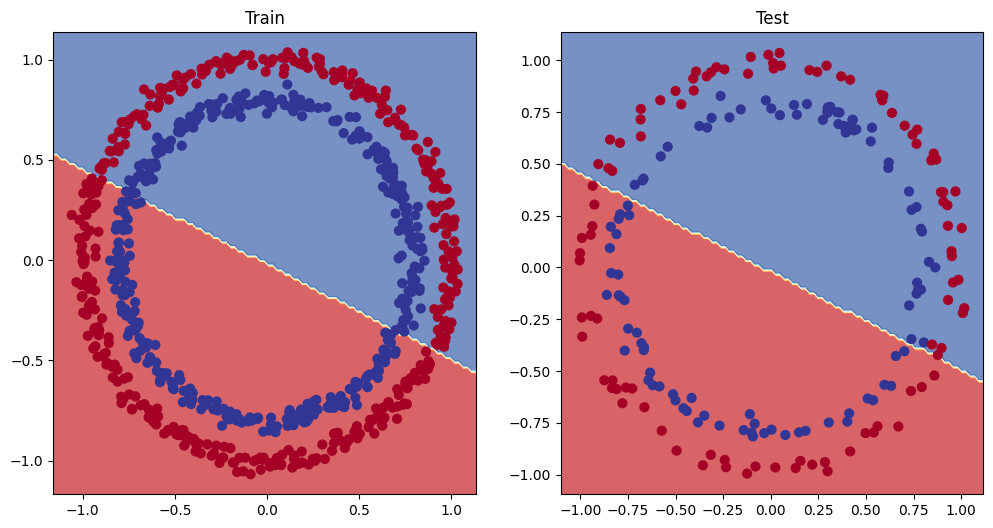

In [ ]:
# plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model_0, X_test, y_test)

### 5. Improving a model (from a model perspective)

- Add more layers - give the model more chances to learn about patterns in the data

- Add more hidden units - go from 5 hidden units to 10 hidden units

- Fit for longer

- Changing the activation functions

- Change the learning rate

- Change the loss functions

These options are all from a model's perspective because they deal directly with the model, rather than the data.

And because these options are all values we (as MLE) can change, they referred as **hyperparameters**

Let's try and improve models by:
- Adding more hidden units: 5->10
- Increase the number of layers: 2->3
- Increase the number of epochs: 100->1000

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)

    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)

    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing ops leverages speed ups where possible bts

model_1 = CircleModelV1().to(device)
model_1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [ ]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.1)

In [ ]:
# Write a training and eval loop for model_1

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### training
  model_1.train()

  # 1. Froward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy(y_true = y_train,
                 y_pred = y_pred)

  # 3. optimize zero grad
  optimizer.zero_grad()

  # 4. backward
  loss.backward()

  # 5. optimize step (gradient descent)
  optimizer.step()

  ### testing
  model_1.eval()
  with torch.inference_mode():

    # 1. forward pass
    y_test_logits = model_1(X_test).squeeze()
    y_test_pred = torch.round(torch.sigmoid(y_test_logits))

    # 2. calculate the loss
    test_loss = loss_fn(y_test_logits, y_test)
    test_acc = accuracy(y_true = y_test, y_pred = y_test_pred)

    # 3. print what's happening
    if epoch % 10 == 0:
      print(f'Epoch: {epoch} | loss: {loss:.5f}, acc: {acc:.2f}% | test_loss: {test_loss:.5f}, test_acc: {test_acc:.2f}')

Epoch: 0 | loss: 0.69396, acc: 50.88% | test_loss: 0.69261, test_acc: 51.00
Epoch: 10 | loss: 0.69369, acc: 50.25% | test_loss: 0.69270, test_acc: 50.00
Epoch: 20 | loss: 0.69351, acc: 50.12% | test_loss: 0.69283, test_acc: 49.50
Epoch: 30 | loss: 0.69339, acc: 50.50% | test_loss: 0.69297, test_acc: 48.00
Epoch: 40 | loss: 0.69329, acc: 50.38% | test_loss: 0.69310, test_acc: 49.00
Epoch: 50 | loss: 0.69322, acc: 49.88% | test_loss: 0.69324, test_acc: 50.00
Epoch: 60 | loss: 0.69317, acc: 49.38% | test_loss: 0.69336, test_acc: 51.50
Epoch: 70 | loss: 0.69312, acc: 49.38% | test_loss: 0.69348, test_acc: 50.50
Epoch: 80 | loss: 0.69309, acc: 50.12% | test_loss: 0.69359, test_acc: 50.00
Epoch: 90 | loss: 0.69307, acc: 50.50% | test_loss: 0.69370, test_acc: 48.50
Epoch: 100 | loss: 0.69305, acc: 50.38% | test_loss: 0.69379, test_acc: 48.00
Epoch: 110 | loss: 0.69303, acc: 50.88% | test_loss: 0.69388, test_acc: 46.50
Epoch: 120 | loss: 0.69302, acc: 50.75% | test_loss: 0.69396, test_acc: 46.

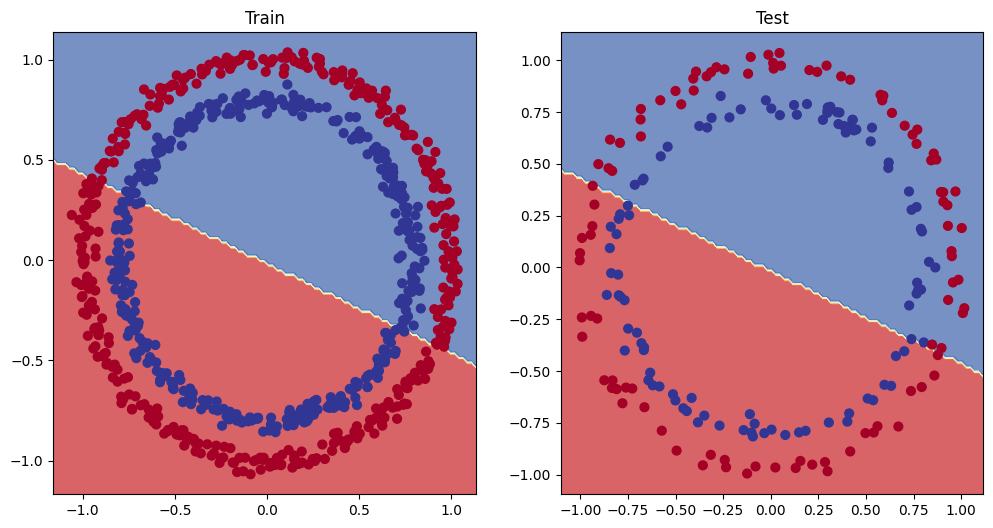

In [ ]:
# plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line.

One way to troubleshoot to a larger problem is to test out a smaller problem.

In [ ]:
# Create some data (same as noteboook 1)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

#check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# Create train and test split
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]

X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the length of each
print(len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression))

80 80 20 20


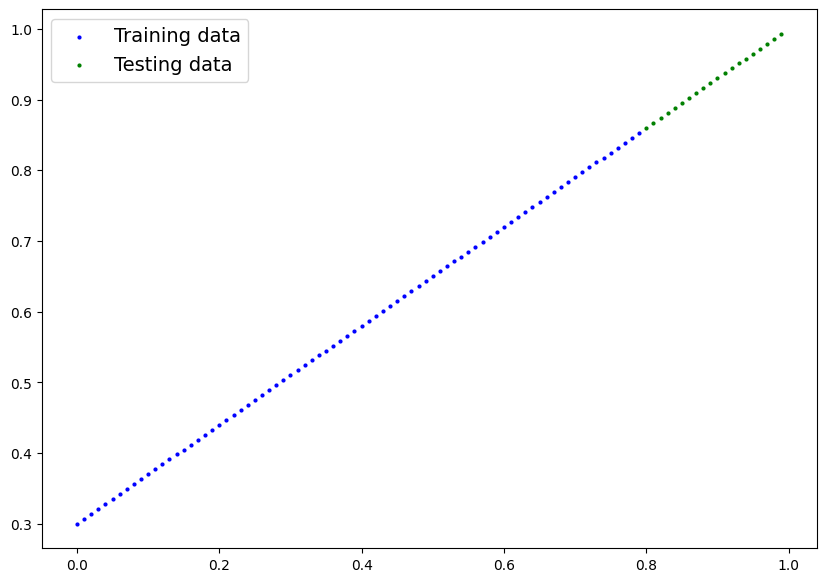

In [ ]:
plot_predictions(train_data = X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression)

In [ ]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
X_train_regression[:5].shape, y_train_regression[:5].shape

(torch.Size([5, 1]), torch.Size([5, 1]))

### 5.2 Adjusting `model_2` to fit a straight line

In [ ]:
# Same architecture as model_1 (but using nn.Sequential() - may be this also take care of forward pass)
model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimizer
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params = model_2.parameters(),
                            lr=0.01)

In [ ]:
# train the model

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the no of epochs
epochs = 1000

# Put the data on taeget device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)

X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):

  # do the forward pass
  y_pred = model_2(X_train_regression)

  # calculate the loss
  loss = loss_fn(y_pred, y_train_regression)

  # optimize zero grad
  optimizer.zero_grad()

  # loss backward
  loss.backward()

  # optimizer step step step
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():

    test_pred = model_2(X_test_regression)

    test_loss = loss_fn(test_pred, y_test_regression)

  # Print what's happening

  if epoch % 100 == 0:
    print(f'Epoch: {epoch} | Loss: {loss:.3f} | test_loss:{test_loss:.5f}')


Epoch: 0 | Loss: 0.760 | test_loss:0.91103
Epoch: 100 | Loss: 0.029 | test_loss:0.00081
Epoch: 200 | Loss: 0.025 | test_loss:0.00209
Epoch: 300 | Loss: 0.021 | test_loss:0.00305
Epoch: 400 | Loss: 0.020 | test_loss:0.00341
Epoch: 500 | Loss: 0.019 | test_loss:0.00387
Epoch: 600 | Loss: 0.019 | test_loss:0.00379
Epoch: 700 | Loss: 0.019 | test_loss:0.00381
Epoch: 800 | Loss: 0.018 | test_loss:0.00329
Epoch: 900 | Loss: 0.018 | test_loss:0.00360


In [ ]:
print(X_train_regression.shape)
print(y_train_regression.shape)
print(X_test_regression.shape)
print(y_test_regression.shape)
print(y_preds.shape)

torch.Size([80, 1])
torch.Size([80, 1])
torch.Size([20, 1])
torch.Size([20, 1])
torch.Size([5, 1])


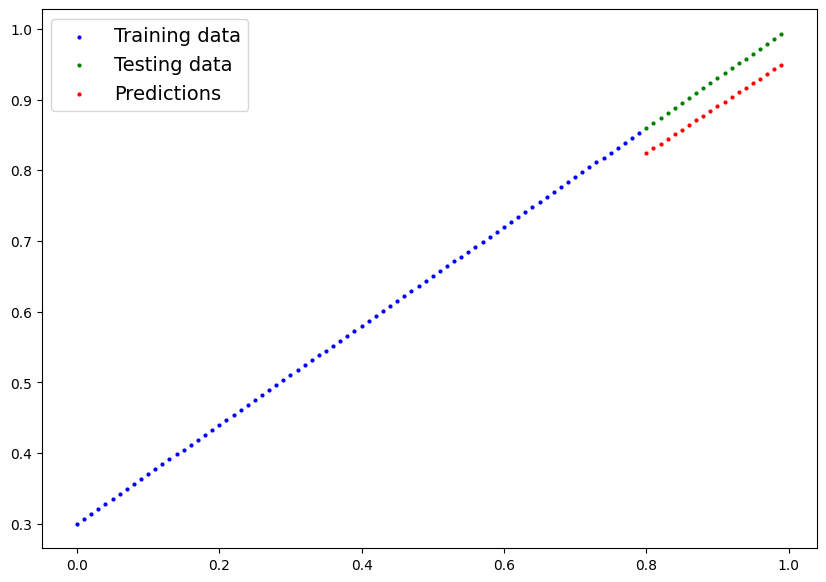

In [ ]:
# Turn on evaluation mode
model_2.eval()

# Make predictions
with torch.inference_mode():

  y_preds = model_2(X_test_regression)

# Plot data and predicitons
plot_predictions(train_data = X_train_regression.cpu(),
                 train_labels = y_train_regression.cpu(),
                 test_data = X_test_regression.cpu(),
                 test_labels = y_test_regression.cpu(),
                 predictions = y_preds.cpu())

### 6. The missing piece: non-linearity

"What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?"

Or in ML terms, an infinite amount (but really it is finite) of linear anf non-linear functions?

### 6.1 Recreating non-linear data (red and blue circles)

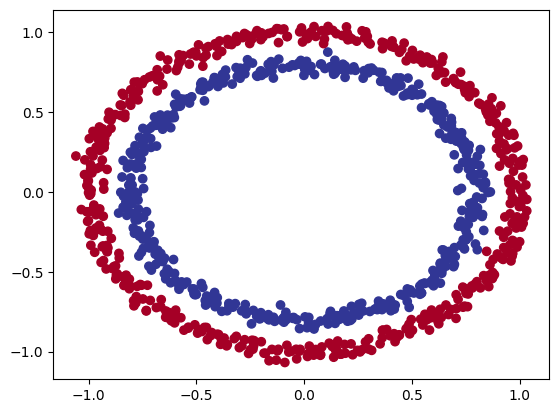

In [ ]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)

plt.scatter(X[:, 0],
            X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu)


In [ ]:
# Convert data to tensors and then to train and test splits

import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


print(X_train[:5], '\n', y_train[:5])

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]]) 
 tensor([1., 0., 0., 0., 1.])


### 6.2 Building the model with non-linearity

- Linear = straight lines
- Non-linear = non-straight lines

Artifical Neural Networks are a large combination of linear (straight) and non-linear(non-straight) functions which are potentially able to find patterns in data

In [ ]:
# BUild a model with non-linear activation functions

from torch import nn

class CircleModelV2(nn.Module):

  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)

    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)

    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

    self.relu = nn.ReLU() # - a non-linear activation function - it keeps the negative values in straight line and put the positive values as per the plotting

  def forward(self, x):

    # Where should we put our non-linear activation functions?
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# Setup loss and optimizer

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_3.parameters(),
                            lr = 0.1)


### 6.3 Training our model with non-linearity

In [ ]:
# Create random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loops through data
epochs = 1000

for epoch in range(epochs):

  # Training
  model_3.train()

  # 1. Forward pass
  y_logits = model_3(X_train).squeeze()

  y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediciton labels

  # 2. Calculate loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy(y_true = y_train,
                  y_pred = y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_3.eval()
  with torch.inference_mode():

    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy(y_true = y_test,
                        y_pred = test_pred)

  # Print what's happening
  if epoch % 100 == 0:
    print(f'Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.2f}%')

Epoch: 0 | Loss: 0.6929, Acc: 50.00% | Test loss: 0.6932, Test acc: 50.00%
Epoch: 100 | Loss: 0.6912, Acc: 52.88% | Test loss: 0.6910, Test acc: 52.50%
Epoch: 200 | Loss: 0.6898, Acc: 53.37% | Test loss: 0.6894, Test acc: 55.00%
Epoch: 300 | Loss: 0.6879, Acc: 53.00% | Test loss: 0.6872, Test acc: 56.00%
Epoch: 400 | Loss: 0.6852, Acc: 52.75% | Test loss: 0.6841, Test acc: 56.50%
Epoch: 500 | Loss: 0.6810, Acc: 52.75% | Test loss: 0.6794, Test acc: 56.50%
Epoch: 600 | Loss: 0.6751, Acc: 54.50% | Test loss: 0.6729, Test acc: 56.00%
Epoch: 700 | Loss: 0.6666, Acc: 58.38% | Test loss: 0.6632, Test acc: 59.00%
Epoch: 800 | Loss: 0.6516, Acc: 64.00% | Test loss: 0.6476, Test acc: 67.50%
Epoch: 900 | Loss: 0.6236, Acc: 74.00% | Test loss: 0.6215, Test acc: 79.00%


### 6.4 Evaluating a model trained with non-linear activation functions

In [ ]:
# Make predicitons
model_3.eval()

with torch.inference_mode():

  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
print(y_preds[:10], '\n', y_test[:10])

tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]) 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


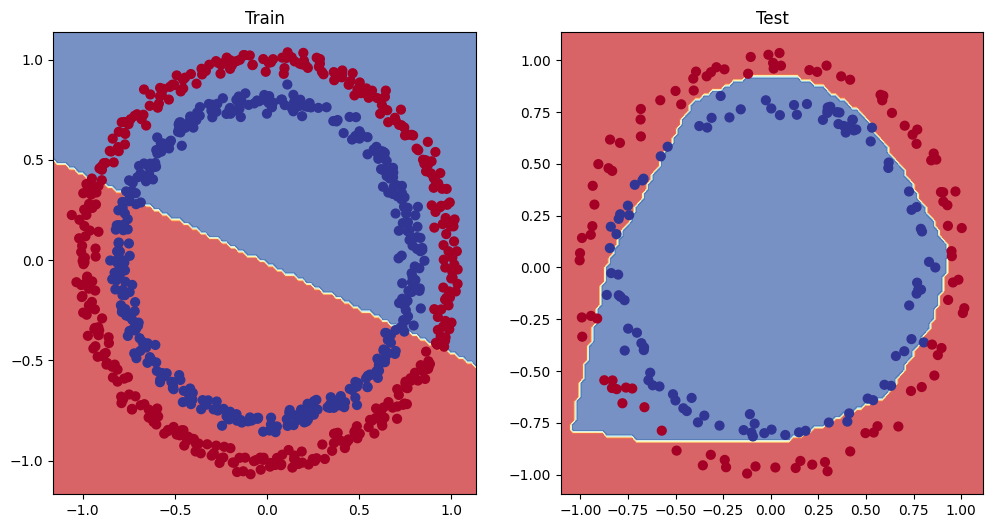

In [ ]:
# plot decison boundaries
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model_3, X_test, y_test) # model_# = has non-linearity

**Challenge:** Can you improve model_3 to do better than 80% accuract on the test data?

In [ ]:
class CircleModelV3(nn.Module):

  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_4 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_5 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_5(self.relu(self.layer_4(self.relu(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))))

model_4 = CircleModelV3().to(device)
model_4

CircleModelV3(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=10, bias=True)
  (layer_4): Linear(in_features=10, out_features=10, bias=True)
  (layer_5): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_4.parameters(), lr = 0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# put all data into targeted device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 2000

for epoch in range(epochs):

  ### training
  model_4.train()

  # do the forward pass
  y_logits = model_4(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy(y_true = y_train,
                 y_pred = y_pred)

  # optimizer zero grad
  optimizer.zero_grad()

  # loss backward
  loss.backward()

  # optimizer step
  optimizer.step()

  ### testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy(y_true = y_test,
                        y_pred = test_pred)

  # print what's happening
  if epoch % 100 == 0:
    print(f'epoch:{epoch} | loss: {loss:.4f} | acc:{acc:.2f} | test loss:{test_loss:.4f} | test acc: {test_acc:.2f}')

epoch:0 | loss: 0.6992 | acc:50.00 | test loss:0.6986 | test acc: 50.00
epoch:100 | loss: 0.6927 | acc:53.00 | test loss:0.6925 | test acc: 52.50
epoch:200 | loss: 0.6926 | acc:52.62 | test loss:0.6923 | test acc: 53.50
epoch:300 | loss: 0.6924 | acc:52.38 | test loss:0.6921 | test acc: 52.50
epoch:400 | loss: 0.6921 | acc:52.25 | test loss:0.6917 | test acc: 52.50
epoch:500 | loss: 0.6916 | acc:52.38 | test loss:0.6912 | test acc: 52.50
epoch:600 | loss: 0.6910 | acc:52.75 | test loss:0.6904 | test acc: 53.00
epoch:700 | loss: 0.6900 | acc:53.50 | test loss:0.6893 | test acc: 53.00
epoch:800 | loss: 0.6887 | acc:54.12 | test loss:0.6877 | test acc: 53.00
epoch:900 | loss: 0.6868 | acc:54.25 | test loss:0.6855 | test acc: 53.50
epoch:1000 | loss: 0.6840 | acc:54.62 | test loss:0.6822 | test acc: 54.00
epoch:1100 | loss: 0.6799 | acc:55.38 | test loss:0.6770 | test acc: 55.00
epoch:1200 | loss: 0.6721 | acc:57.63 | test loss:0.6679 | test acc: 58.50
epoch:1300 | loss: 0.6533 | acc:64.12

In [ ]:
# Make predicitons
model_3.eval()

with torch.inference_mode():

  y_preds = torch.round(torch.sigmoid(model_4(X_test))).squeeze()
print(y_preds[:10], '\n', y_test[:10])

tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]) 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


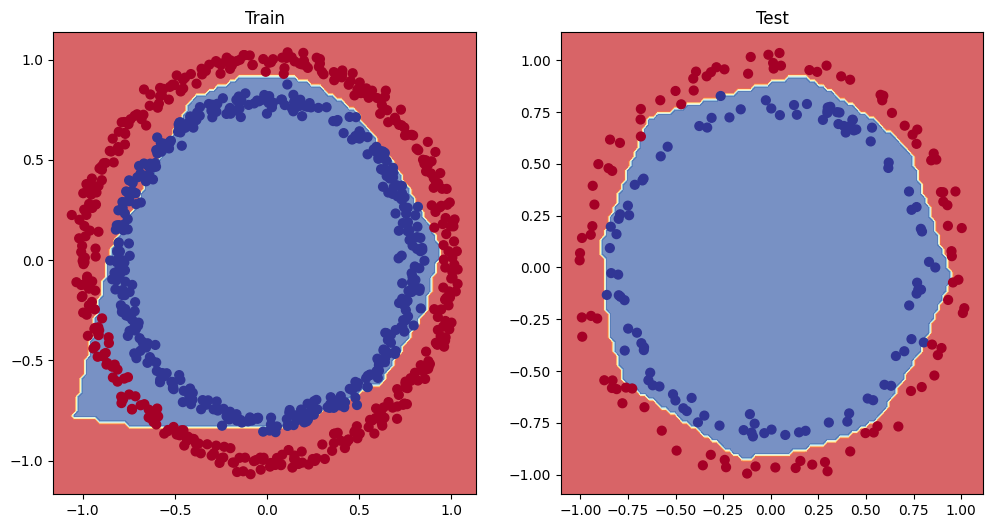

In [ ]:
# plot decison boundaries
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model_3, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model_4, X_test, y_test) # model_# = has non-linearity

### 7. Replicating non-linear activation functions

Neural Networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

These tools are linear & non-linear functions.

In [ ]:
# Create a tensor

A = torch.arange(-10, 10, 1, dtype = torch.float)
A.dtype

torch.float32

In [ ]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

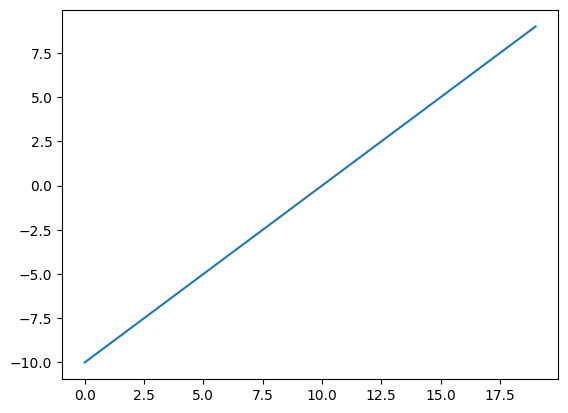

In [ ]:
# Visualize
plt.plot(A)

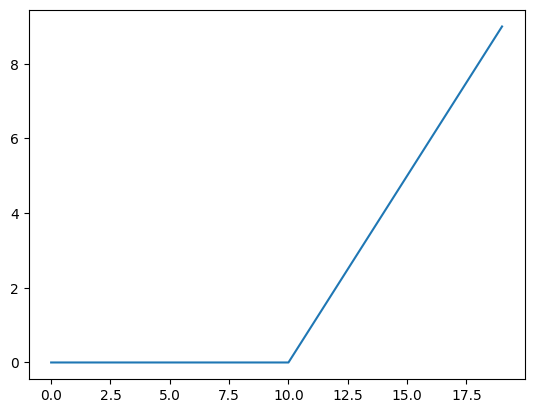

In [ ]:
plt.plot(torch.relu(A)) # Plot ReLU activation fn

In [ ]:
# We are going to see concept of relu in action

def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x) # inputs must be tensors

print(relu(A))

# we are finding max b/w the 0 and the passed tensor i.e. A in this case. So max b/w 0 and -ve value is 0 so it returns 0 for all the -ve values and keeping the +ve values as they are > 0.

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])


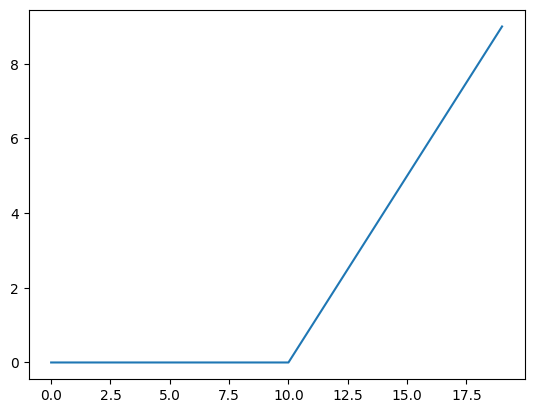

In [ ]:
# our function's o/p.
plt.plot(relu(A))

In [ ]:
# Now let's do the same for another activation function - sigmoid
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

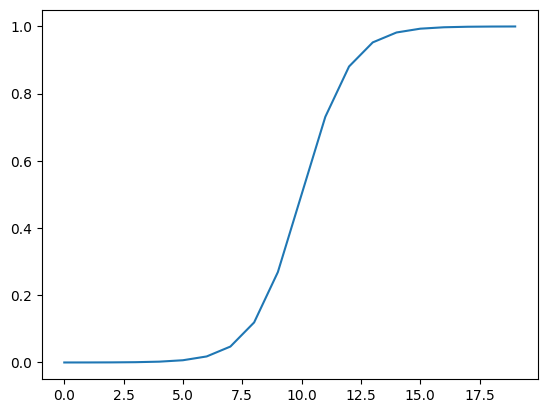

In [ ]:
plt.plot(torch.sigmoid(A)) # torch's inbuilt sigmoid

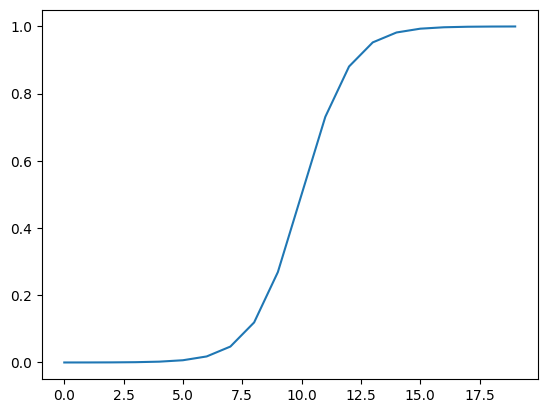

In [ ]:
plt.plot(sigmoid(A)) # our function's output

### 8. Putting it all together with a multi-class classification problem

* Binary classification = one thing or another (spam or not spa, fraud or not fraud etc)

* Multi-class classification = more than one thing or another (dog, cat, hen etc)

### 8.1 Creating a toy multi-class dataset

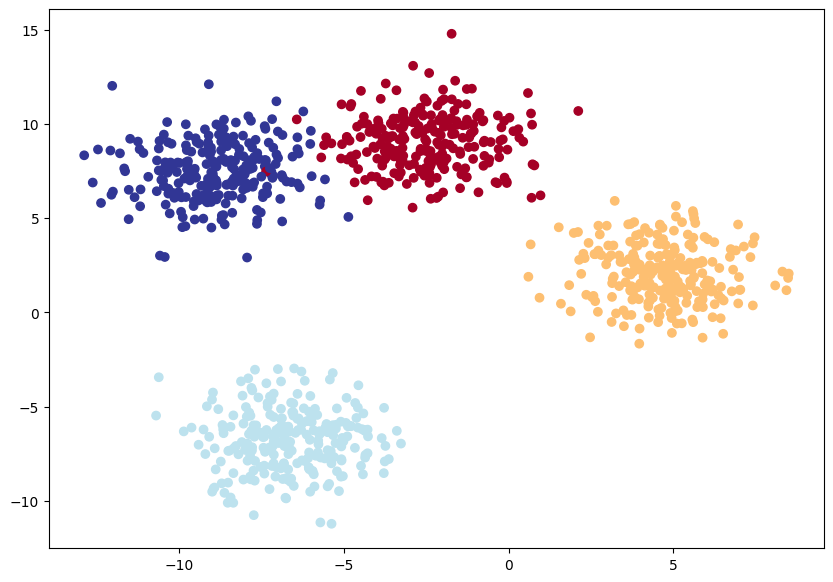

In [ ]:
# Import dependencies

import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creations
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples = 1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5, #give the clusters a little shake up
                            random_state = RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test split
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size = 0.2, random_state = RANDOM_SEED)

# X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
# X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# 4. Plot data (Visualize x 3)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1],
            c = y_blob, cmap = plt.cm.RdYlBu);

### 8.2 Building a multi-class classification model in PyTorch

In [ ]:
# Creating device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

'cpu'

In [ ]:
# Build a multi-class classification model

class BlobModel(nn.Module):
  def __init__(self, input_features, out_features, hidden_units = 8):
    """
    Initializes multi-class classification model.

    Args:
      input features (int): Number of input features to the model.
      out_features (int): Number of output features to the mdoel (number of output classes).
      hidden_units (int): Number of hidden units between layers, default 8.
    """

    super().__init__()

    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = out_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Create an instance of blob model and send t target deivce
model_5 = BlobModel(input_features = 2,
                    out_features = 4, # based on the number of classes
                    hidden_units = 8).to(device)

model_5


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
X_blob_train.shape, y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [ ]:
torch.unique(y_blob_train) # just another way probably to see the clases

tensor([0, 1, 2, 3])

### 8.3 Create a loss function and an optimizer for multi-class classification model



In [ ]:
# Create loss
loss_fn = nn.CrossEntropyLoss()
'''
When to use it: Multi-class classification — when your model has to pick one class out of many (e.g. is this image a cat, dog, or bird?).
For just 2 classes (yes/no, 0/1) you use BCEWithLogitsLoss. For 3+ classes you use CrossEntropyLoss.

Why it works — simple intuition:
Say your model outputs probabilities for 3 classes: [0.7, 0.2, 0.1] and the correct answer is class 0.
Cross entropy basically asks — "how confident were you about the right answer?" — and penalizes you based on that. If you said 0.7 for the correct class, penalty is small. If you said 0.1 for the correct class, penalty is huge.
It pushes the model to be as confident as possible about the correct class.
'''

# Create an optimizer - optmizers update our model's parameter to try and reduce the loss
optimizer = torch.optim.SGD(params = model_5.parameters(),
                            lr = 0.1) # lr is hyperparameter you can change

### 8.4 Building a training loop (Getting prediciton probabilities for a multi-class PyTorch mdoel)

In order to evaluate and train and test our model, we need to convert our model's output(logits) to prediciton probabilities and then to prediction labels

Logits (raw o/p of the models) -> pred probs (use `torch.softmax`) -> pred labels (use `argmax` to predict labels)



In [ ]:
# Let's get some raw outputs of our model (logits)

model_5.eval()
with torch.inference_mode():
  y_logits = model_5(X_blob_test).to(device)

  print(y_logits[:10])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])


In [ ]:
print(y_blob_test[:10])

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])


In [ ]:
# Convert our mdoel's logit outputs to prediciton probabilities
print(f'Raw output or before crushing it: - {y_logits[:5]}', '\n')

y_pred_probs = torch.softmax(y_logits, dim=1)

print(f'After squashing between 0, 1: - {y_pred_probs[:5]}')

Raw output or before crushing it: - tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]]) 

After squashing between 0, 1: - tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [ ]:
torch.sum(y_pred_probs[0])

tensor(1.0000)

In [ ]:
print(0.2979 + 0.3062 + 0.2190 + 0.1769)  # same as above.

# confirms that softmax squash the classes in such a way that there output is always 1.
print(0.2832 + 0.2280 + 0.2874 + 0.2014)
# after every run the numbers could change but the point is the sum of the predicting multiple classes always leads to 1.

1.0
1.0


In [ ]:
print(max(y_pred_probs[0])) # as per 1st row (0.2979, 0.3062, 0.2190, 0.1769) - it says the prob of class 0 is - 0.2979, class 1 - 0.3062, class 2 - 0.2190, class 3 - 0.1769. So prob could be class 1 since it is the max out of all row 0.

tensor(0.3244)


In [ ]:
torch.argmax(y_pred_probs[0])
'''
argmax returns the index of the highest value — not the value itself.
In classification, your model outputs probabilities like:
pythonprobs = [0.59, 0.24, 0.17]  # class 0, class 1, class 2
You don't care about the actual probability values — you just want to know which class won. That's what argmax gives you:
pythontorch.argmax(probs)  # → 0  (index of 0.59, the highest)
So it's basically the final step that converts probabilities → predicted class label.
'''

"\nargmax returns the index of the highest value — not the value itself.\nIn classification, your model outputs probabilities like:\npythonprobs = [0.59, 0.24, 0.17]  # class 0, class 1, class 2\nYou don't care about the actual probability values — you just want to know which class won. That's what argmax gives you:\npythontorch.argmax(probs)  # → 0  (index of 0.59, the highest)\nSo it's basically the final step that converts probabilities → predicted class label.\n"

In [ ]:
# Convert our model's prediciton probabilities to predition labels

y_preds = torch.argmax(y_pred_probs, dim=1)
print(y_preds)

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])


In [ ]:
print(y_blob_test) # model is predicting without training hence the value would be random but this confirm the format of the probs. Predict labels for each row using armax

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])


### 8.5 Creating a training and testing loops for multi-class PyTorch model

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set number of epochs

epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):

  ### Training
  model_5.train()

  # Do the forward pass
  y_logits = model_5(X_blob_train).to(device)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  # calcualte the loss
  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy(y_true = y_blob_train,
                 y_pred = y_pred)

  # optimize zero grad
  optimizer.zero_grad()

  # loss backward
  loss.backward()

  # optimizer step step step
  optimizer.step()

  ### Testing
  model_5.eval()
  with torch.inference_mode():
    test_logits = model_5(X_blob_test).to(device)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy(y_true = y_blob_test,
                        y_pred = test_pred)

  # what's happening
  if epoch % 10 == 0:
    print(f'epoch:{epoch} | loss:{loss:.4f} | acc:{acc:.4f} | test loss:{test_loss:.4f} | test acc: {test_acc:.2f}')


epoch:0 | loss:1.1588 | acc:40.3750 | test loss:1.0755 | test acc: 48.00
epoch:10 | loss:0.6448 | acc:96.7500 | test loss:0.6607 | test acc: 97.50
epoch:20 | loss:0.4254 | acc:98.5000 | test loss:0.4307 | test acc: 100.00
epoch:30 | loss:0.2529 | acc:99.1250 | test loss:0.2451 | test acc: 99.50
epoch:40 | loss:0.1123 | acc:99.2500 | test loss:0.1023 | test acc: 99.50
epoch:50 | loss:0.0663 | acc:99.2500 | test loss:0.0585 | test acc: 99.50
epoch:60 | loss:0.0507 | acc:99.2500 | test loss:0.0429 | test acc: 99.50
epoch:70 | loss:0.0430 | acc:99.2500 | test loss:0.0349 | test acc: 99.50
epoch:80 | loss:0.0384 | acc:99.2500 | test loss:0.0299 | test acc: 99.50
epoch:90 | loss:0.0352 | acc:99.2500 | test loss:0.0266 | test acc: 99.50


### 8.6 Making and evaluating predicitons with a PyTorch multi-class model


In [ ]:
# Make predicitons
model_5.eval()

with torch.inference_mode():
  y_logits = model_5(X_blob_test)

print(y_logits[:10])

tensor([[-0.6249,  5.9860, -7.6323, -8.4470],
        [-2.1738, -6.3750, -3.7202,  3.1203],
        [-3.4102, -3.8958,  3.1567, -2.6119],
        [-1.1505,  4.1962, -3.8472, -4.8820],
        [ 3.7548, -1.3391, -9.1422, -6.9466],
        [-2.8211, -7.5767, -4.2944,  3.7944],
        [-3.0306, -3.3328,  2.7955, -2.1374],
        [ 3.3761, -4.0375, -6.8987, -3.5503],
        [-4.3620, -4.9904,  3.8123, -3.3814],
        [ 3.5012, -3.0281, -7.5401, -4.7064]])


In [ ]:
# Go from logits -> prediction probabilities

y_pred_probs = torch.softmax(y_logits, dim=1)

print(y_pred_probs[:10])

tensor([[1.3437e-03, 9.9865e-01, 1.2164e-06, 5.3854e-07],
        [4.9905e-03, 7.4740e-05, 1.0630e-03, 9.9387e-01],
        [1.3985e-03, 8.6060e-04, 9.9463e-01, 3.1073e-03],
        [4.7389e-03, 9.9483e-01, 3.1956e-04, 1.1353e-04],
        [9.9388e-01, 6.0966e-03, 2.4904e-06, 2.2378e-05],
        [1.3372e-03, 1.1504e-05, 3.0644e-04, 9.9834e-01],
        [2.9138e-03, 2.1537e-03, 9.8781e-01, 7.1181e-03],
        [9.9838e-01, 6.0198e-04, 3.4435e-05, 9.7989e-04],
        [2.8147e-04, 1.5016e-04, 9.9882e-01, 7.5044e-04],
        [9.9825e-01, 1.4575e-03, 1.5997e-05, 2.7210e-04]])


In [ ]:
print(y_blob_test)

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])


In [ ]:
# go from pred probs to pred labels
y_preds = torch.argmax(y_pred_probs, dim=1)

print(y_preds)

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 0, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])


In [ ]:
print(y_blob_test == y_preds)

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True, 

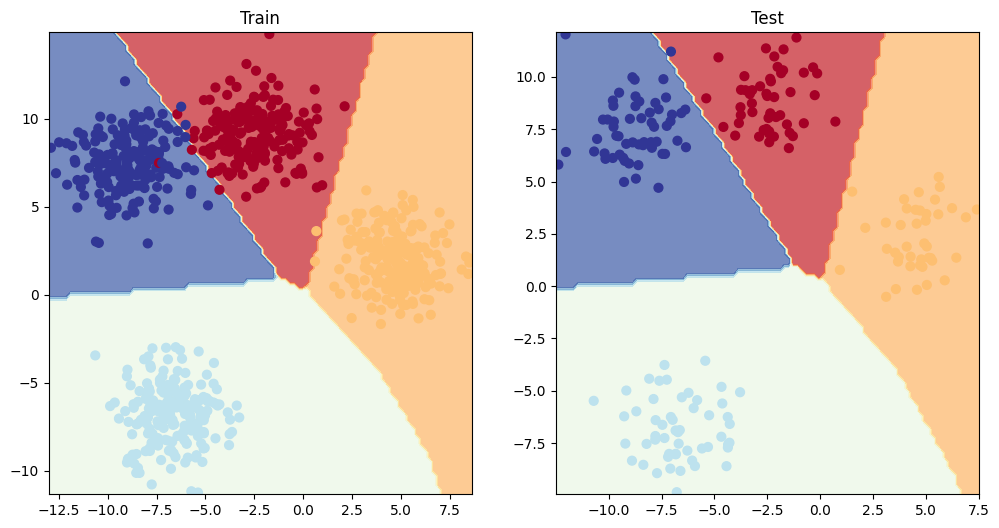

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_5, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_5, X_blob_test, y_blob_test)

### 9. A few more classification metrics...(to evaluate our classification model)

* Accuracy - out of 100 samples, how many does our model get right

* Precision

* Recall

* Accuracy

* Confusion matrix

* Classification report

See this article for when to use precision/recall: https://towardsdatascience.com/beyond-accuracy-other-classification-metrics-you-should-know-in-machine-learning-ea671be83bb7/

If you want access to lot og PyTorch metrics, see TorchMetrics: https://torchmetrics.readthedocs.io/en/v0.8.2/metrics.html

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 14.9 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

# Setup metric
torchmetric_acc = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetric_acc(y_preds, y_blob_test)

tensor(0.9950)

## EXERCISES
For reference: https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/02_pytorch_classification_exercise_solutions.ipynb

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

'cpu'

In [ ]:
# Make a binary classification dataset with Scikit-Learn's make_moons() function.
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torchmetrics import Accuracy

# 1. For consistency, the dataset should have 1000 samples and a random_state=42.
n_samples = 1000
random_State = 42
X, y = make_moons(n_samples,
                  noise = 0.03,
                  random_state=42)
# 2. Turn the data into PyTorch tensors. Split the data into training and test sets using train_test_split with 80% training and 20% testing.
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_tet = train_test_split(X, y, test_size = 0.2, random_state = 42)

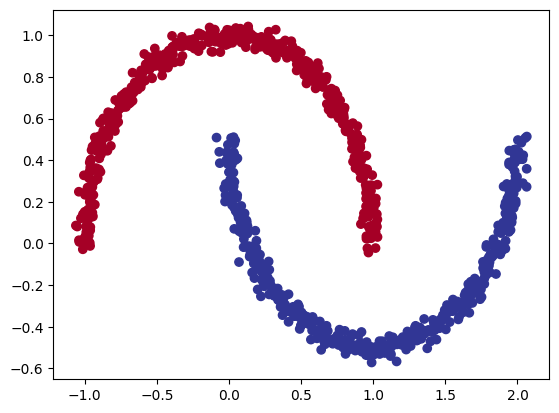

In [ ]:
plt.scatter(X[:, 0],
            X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu)

In [ ]:
print(X_train[:5], '\n', X_test[:5], '\n', y_train[:5], '\n', y_test[:5])

tensor([[ 1.9758,  0.2076],
        [-0.9608,  0.4007],
        [-0.0986,  1.0231],
        [-0.1083,  0.9919],
        [ 0.3767, -0.2620]]) 
 tensor([[ 0.5172, -0.3785],
        [ 0.7536,  0.6871],
        [ 1.2408, -0.4597],
        [ 0.6236,  0.8408],
        [ 1.8526, -0.0454]]) 
 tensor([1., 0., 0., 0., 1.]) 
 tensor([1., 0., 1., 0., 1.])


In [ ]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([200, 2]) torch.Size([800]) torch.Size([200])


In [ ]:
# Build a model by subclassing nn.Module that incorporates non-linear activation functions and is capable of fitting the data you created in 1.

#     Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

class MakeMoons(nn.Module):

  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.relu = nn.ReLU()
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.relu = nn.ReLU()
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_6 = MakeMoons().to(device)

model_6

MakeMoons(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (relu): ReLU()
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Setup a binary classification compatible loss function and optimizer to use when training the model.

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_6.parameters(),
                            lr = 0.1)

acc_fn = Accuracy(task='binary', num_classes = 2).to(device)

In [ ]:
# Create a training and testing loop to fit the model you created in 2 to the data you created in 1.

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

for epoch in range(epochs):

  # Training
  model_6.train()

  # do the forward pass
  y_logits = model_6(X_train).squeeze().to(device)
  y_preds = torch.sigmoid(y_logits)

  # To measure model accuracy, you can create your own accuracy function or use the accuracy function in TorchMetrics.
  # calculate the loss
  loss = loss_fn(y_logits, y_train)
  # acc = accuracy(y_true = y_train,
  #                y_pred = y_preds)
  acc = acc_fn(y_preds, y_train)

  # optimize zero grad
  optimizer.zero_grad()

  # loss backward
  loss.backward()

  # calculate step step step
  optimizer.step()

  ### testing
  model_6.eval()
  with torch.inference_mode():
    test_logits = model_6(X_test).squeeze().to(device)
    test_preds = torch.sigmoid(test_logits)

    test_loss = loss_fn(test_logits, y_test)
    test_acc=acc_fn(test_preds, y_test)

  # The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

  # print what's happening

  if epoch % 10 == 0:
    print(f'epoch:{epoch} | loss:{loss:.4f} | acc:{acc:.4f} | test loss:{test_loss:.4f} | test acc:{test_acc:.2f}')

# Train the model for long enough for it to reach over 96% accuracy.


epoch:0 | loss:0.6954 | acc:0.3775 | test loss:0.6946 | test acc:0.50
epoch:10 | loss:0.6820 | acc:0.7650 | test loss:0.6821 | test acc:0.73
epoch:20 | loss:0.6679 | acc:0.7975 | test loss:0.6692 | test acc:0.77
epoch:30 | loss:0.6507 | acc:0.7763 | test loss:0.6531 | test acc:0.73
epoch:40 | loss:0.6261 | acc:0.7613 | test loss:0.6301 | test acc:0.69
epoch:50 | loss:0.5933 | acc:0.7513 | test loss:0.5996 | test acc:0.71
epoch:60 | loss:0.5528 | acc:0.7613 | test loss:0.5613 | test acc:0.73
epoch:70 | loss:0.5071 | acc:0.7725 | test loss:0.5180 | test acc:0.75
epoch:80 | loss:0.4610 | acc:0.7862 | test loss:0.4742 | test acc:0.75
epoch:90 | loss:0.4200 | acc:0.8025 | test loss:0.4349 | test acc:0.75
epoch:100 | loss:0.3864 | acc:0.8188 | test loss:0.4020 | test acc:0.77
epoch:110 | loss:0.3593 | acc:0.8300 | test loss:0.3746 | test acc:0.79
epoch:120 | loss:0.3371 | acc:0.8413 | test loss:0.3513 | test acc:0.80
epoch:130 | loss:0.3184 | acc:0.8487 | test loss:0.3309 | test acc:0.81
epo

In [ ]:
torch.unique(y)

tensor([0., 1.])

In [ ]:
print(y_logits.shape, y_train.shape)

torch.Size([800]) torch.Size([800])


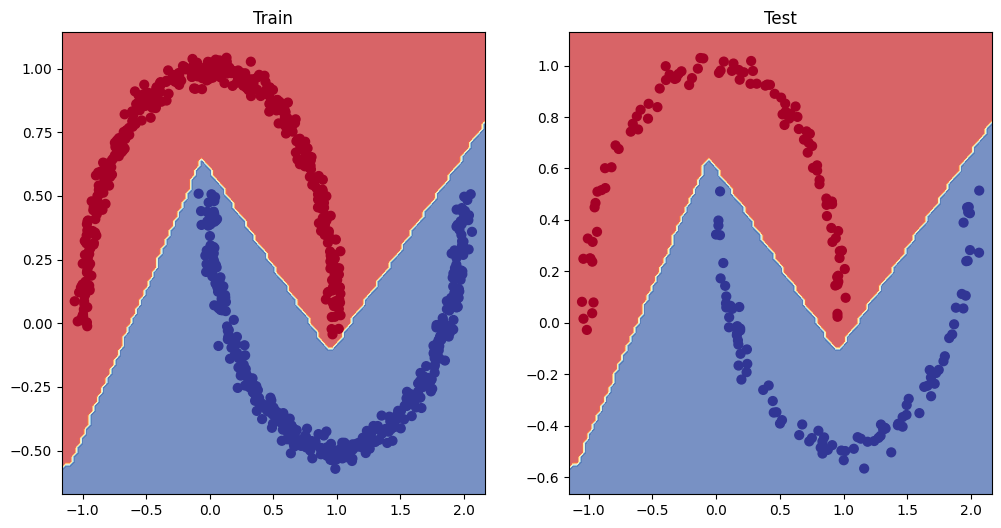

In [ ]:
# Make predicitons
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_6, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_6, X_test, y_test)

In [ ]:
B = torch.arange(-10, 10, 1).type(torch.float)

In [ ]:
B

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

In [ ]:
# Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
def tanh(x):
  return (torch.exp(x)-torch.exp(-x))/(torch.exp(x)+torch.exp(-x))


In [ ]:
print(tanh(B)) # our replicated fn

tensor([-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.9999, -0.9993, -0.9951,
        -0.9640, -0.7616,  0.0000,  0.7616,  0.9640,  0.9951,  0.9993,  0.9999,
         1.0000,  1.0000,  1.0000,  1.0000])


In [ ]:
print(torch.tanh(B)) # pytorch tanh

tensor([-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.9999, -0.9993, -0.9951,
        -0.9640, -0.7616,  0.0000,  0.7616,  0.9640,  0.9951,  0.9993,  0.9999,
         1.0000,  1.0000,  1.0000,  1.0000])


**Tanh** squashes a real-valued number to the range [-1, 1]. It’s non-linear. But unlike Sigmoid, its output is zero-centered. Therefore, in practice the tanh non-linearity is always preferred to the sigmoid nonlinearity.

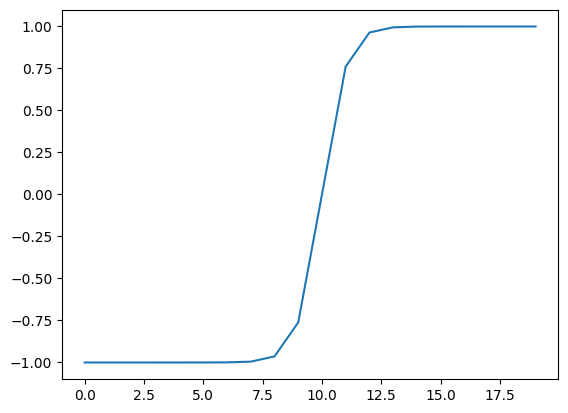

In [ ]:
plt.plot(torch.tanh(B))

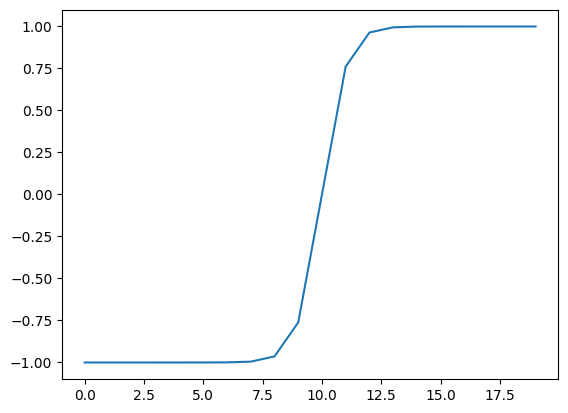

In [ ]:
plt.plot(tanh(B))

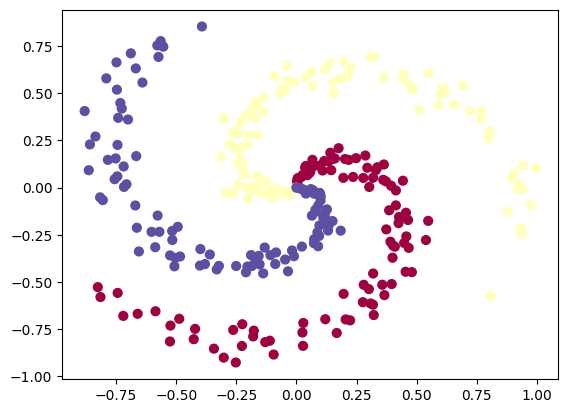

In [ ]:
# Create a multi-class dataset using the spirals data creation function from CS231n (see below for the code).
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()


In [ ]:
print(torch.tensor(y).unique())

tensor([0, 1, 2], dtype=torch.uint8)


In [ ]:
# Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).

class Spirals(nn.Module):

  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    # self.relu = nn.ReLU()
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    # self.relu = nn.ReLU()
    self.layer_3 = nn.Linear(in_features = 10, out_features = 3)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_7 = Spirals()
model_7

Spirals(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)

In [ ]:
# Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params = model_7.parameters(),
                             lr = 0.1)
acc_fn = Accuracy(task='multiclass', num_classes = 3)

In [ ]:
# Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like).

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train = torch.from_numpy(X_train).type(torch.float).to(device)
X_test = torch.from_numpy(X_test).type(torch.float).to(device)
y_train = torch.from_numpy(y_train).type(torch.long).to(device)
y_test = torch.from_numpy(y_test).type(torch.long).to(device)

for epoch in range(epochs):

  # Training
  model_7.train()
  # do the forward pass
  y_logits = model_7(X_train).squeeze().to(device)
  y_preds = torch.softmax(y_logits, dim=1).to(device)

  # calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_preds, y_train)

  # optimize zero grad
  optimizer.zero_grad()

  # loss backward
  loss.backward()

  # optimizer step step step
  optimizer.step()

  # testing
  model_7.eval()
  with torch.inference_mode():
    test_logits = model_7(X_test).squeeze().to(device)
    test_preds = torch.softmax(test_logits, dim=1).to(device)

    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_preds, y_test)

  if epoch % 10 == 0:
    print(f'epoch:{epoch} | loss:{loss:.4f} | acc:{acc:.2f} | test loss:{test_loss:.4f} | test acc:{test_acc:.2f}')

epoch:0 | loss:1.1169 | acc:0.32 | test loss:1.0945 | test acc:0.27
epoch:10 | loss:0.8313 | acc:0.53 | test loss:0.8571 | test acc:0.45
epoch:20 | loss:0.4988 | acc:0.80 | test loss:0.7045 | test acc:0.70
epoch:30 | loss:0.3404 | acc:0.83 | test loss:0.4215 | test acc:0.75
epoch:40 | loss:0.2143 | acc:0.90 | test loss:0.2508 | test acc:0.88
epoch:50 | loss:0.1584 | acc:0.95 | test loss:0.1858 | test acc:0.88
epoch:60 | loss:0.1265 | acc:0.95 | test loss:0.1528 | test acc:0.93
epoch:70 | loss:0.0958 | acc:0.98 | test loss:0.1249 | test acc:0.97
epoch:80 | loss:0.0747 | acc:0.98 | test loss:0.1184 | test acc:0.97
epoch:90 | loss:0.0619 | acc:0.99 | test loss:0.0668 | test acc:0.97
epoch:100 | loss:0.0544 | acc:0.99 | test loss:0.0544 | test acc:0.97
epoch:110 | loss:0.0494 | acc:0.99 | test loss:0.0411 | test acc:1.00
epoch:120 | loss:0.0457 | acc:0.99 | test loss:0.0375 | test acc:0.98
epoch:130 | loss:0.0430 | acc:0.99 | test loss:0.0317 | test acc:0.98
epoch:140 | loss:0.0408 | acc:0

**Note:** Why torch.long (i.e. int64)?

- torch.long is used for class labels in multi-class classification.
Think of it this way — when you have 4 classes (0, 1, 2, 3), PyTorch's CrossEntropyLoss needs to use those numbers as index positions to look up the correct class internally. Indexes must be whole numbers, and specifically PyTorch requires them to be int64 (which is what torch.long is).

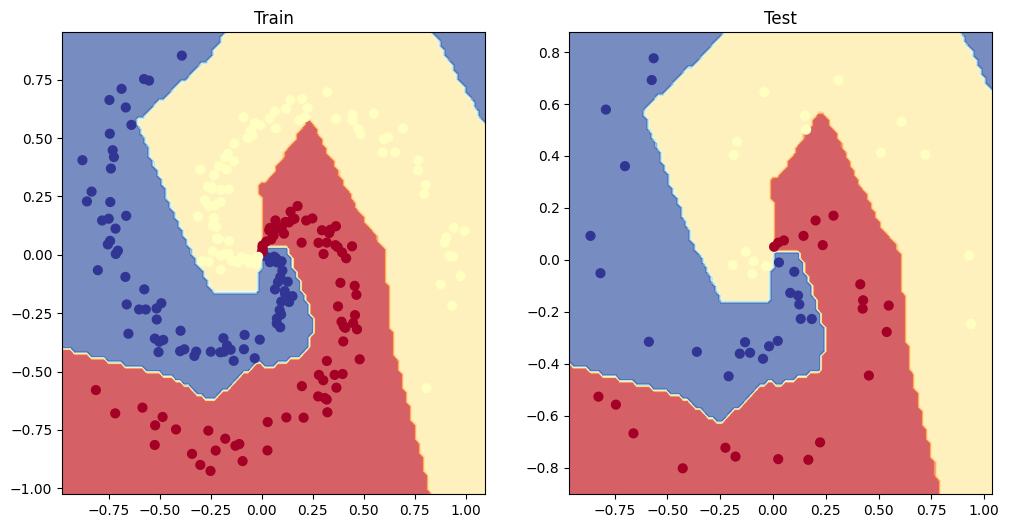

In [ ]:
# Make predicitons
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_7, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_7, X_test, y_test)
